In [11]:
import pandas as pd
import numpy as np
import os
from sklearn.linear_model import LogisticRegression

In [13]:

# --- 1. SETUP & DATA LOADING ---
# Ensure 'Loan_Data.csv' is in the same folder as this script
file_name = 'Loan_Data.csv'
if not os.path.exists(file_name):
    print(f"ERROR: '{file_name}' not found. Current Directory: {os.getcwd()}")
else:
    df = pd.read_csv(file_name)

    # Define the features as in the Data File
    features = [
        'credit_lines_outstanding', 
        'loan_amt_outstanding', 
        'total_debt_outstanding', 
        'income', 
        'years_employed', 
        'fico_score'
    ]
    
    X = df[features]
    y = df['default']

    # --- 2. TRAIN THE PD MODEL ---
    # We use Logistic Regression for its high interpretability in Risk Management
    pd_model = LogisticRegression(max_iter=1000)
    pd_model.fit(X, y)
    print("--- Model Training Complete ---")

    # --- 3. THE VALUATION FUNCTION ---
    def calculate_expected_loss(credit_lines, loan_amt, total_debt, income, years_employed, fico_score):
        """
        Calculates the Expected Loss (EL) on a loan.
        Formula: EL = PD * LGD * EAD
        - LGD (Loss Given Default) is 0.90 based on a 10% recovery rate.
        - EAD (Exposure at Default) is the current outstanding loan amount.
        """
        
        # Create input DataFrame to avoid UserWarnings and ensure feature names match
        input_df = pd.DataFrame([{
            'credit_lines_outstanding': credit_lines,
            'loan_amt_outstanding': loan_amt,
            'total_debt_outstanding': total_debt,
            'income': income,
            'years_employed': years_employed,
            'fico_score': fico_score
        }])
        
        # 1. Predict Probability of Default (PD)
        # We take the probability of the positive class (1)
        pd_val = pd_model.predict_proba(input_df)[0][1]
        
        # 2. Financial Logic
        lgd = 0.90  # 90% Loss (10% Recovery)
        ead = loan_amt # Exposure is the loan amount
        
        # 3. Calculate EL
        expected_loss = pd_val * lgd * ead
        
        return pd_val, expected_loss


    # --- 4. EXECUTION & TESTING ---
    # Test with a sample borrower (High Risk Profile)
    # Params: lines, loan_amt, total_debt, income, years, fico
    prob, loss = calculate_expected_loss(5, 2000, 8000, 26000, 2, 570)

    print(f"\n--- Risk Assessment Results ---")
    print(f"Probability of Default: {prob:.2%}")
    print(f"Expected Loss: ${loss:,.2f}")
    print(f"-------------------------------")

    # Optional: Test with a Low Risk Profile to verify model logic
    prob_low, loss_low = calculate_expected_loss(0, 2000, 1000, 80000, 10, 750)
    print(f"Comparison (Low Risk Borrower) PD: {prob_low:.2%}")

--- Model Training Complete ---

--- Risk Assessment Results ---
Probability of Default: 100.00%
Expected Loss: $1,800.00
-------------------------------
Comparison (Low Risk Borrower) PD: 0.00%


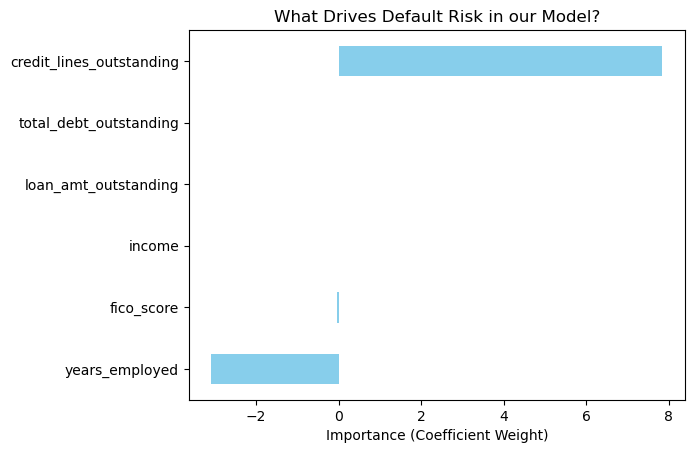

In [14]:
import matplotlib.pyplot as plt

# Extracting weights (coefficients)
weights = pd.Series(pd_model.coef_[0], index=features)

# Plotting
weights.sort_values().plot(kind='barh', color='skyblue')
plt.title('What Drives Default Risk in our Model?')
plt.xlabel('Importance (Coefficient Weight)')
plt.show()